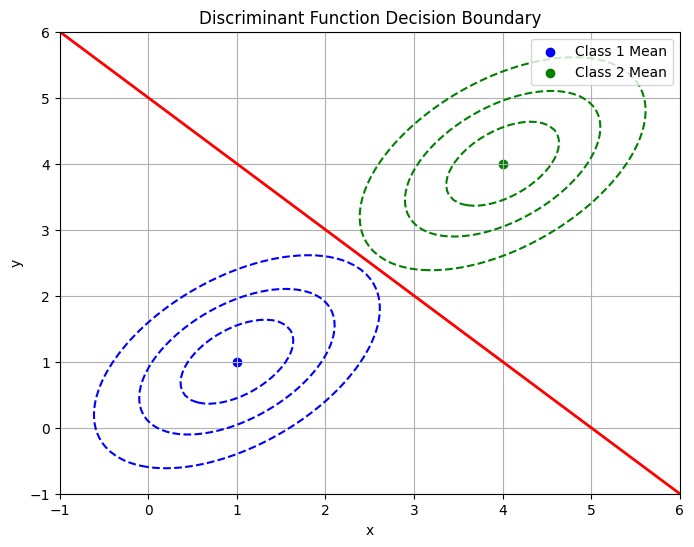

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Parameters for two Gaussian classes
mean1 = [1, 1]
mean2 = [4, 4]
cov = [[1, 0.5], [0.5, 1]]

# Discriminant function for two classes
def discriminant(x, mean1, mean2, cov):
    inv_cov = np.linalg.inv(cov)
    return (x - mean1) @ inv_cov @ (x - mean1).T - (x - mean2) @ inv_cov @ (x - mean2).T

# Grid for plotting
x = np.linspace(-1, 6, 100)
y = np.linspace(-1, 6, 100)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        pt = np.array([X[i, j], Y[i, j]])
        Z[i, j] = discriminant(pt, mean1, mean2, cov)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=2)
plt.title('Discriminant Function Decision Boundary')
plt.xlabel('x')
plt.ylabel('y')

# Plot Gaussian contours for both classes
rv1 = multivariate_normal(mean1, cov)
rv2 = multivariate_normal(mean2, cov)
plt.contour(X, Y, rv1.pdf(np.dstack((X, Y))), levels=3, colors='blue', linestyles='dashed')
plt.contour(X, Y, rv2.pdf(np.dstack((X, Y))), levels=3, colors='green', linestyles='dashed')
plt.scatter(*mean1, color='blue', label='Class 1 Mean')
plt.scatter(*mean2, color='green', label='Class 2 Mean')
plt.legend()
plt.grid(True)
plt.show()

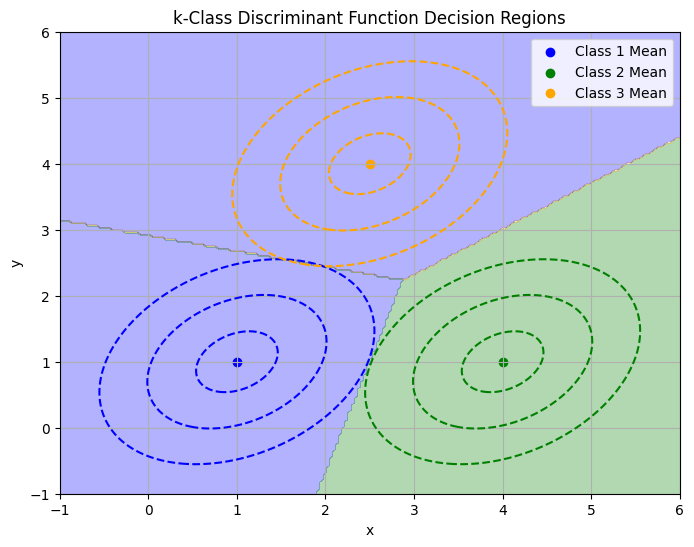

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Parameters for 3 Gaussian classes
means = [np.array([1, 1]), np.array([4, 1]), np.array([2.5, 4])]
cov = np.array([[1, 0.3], [0.3, 1]])
colors = ['blue', 'green', 'orange']

# Discriminant function for k classes
def discriminant(x, means, cov):
    inv_cov = np.linalg.inv(cov)
    scores = [-(x - m) @ inv_cov @ (x - m).T for m in means]
    return np.argmax(scores)

# Grid for plotting
x = np.linspace(-1, 6, 200)
y = np.linspace(-1, 6, 200)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X, dtype=int)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        pt = np.array([X[i, j], Y[i, j]])
        Z[i, j] = discriminant(pt, means, cov)

# Plot decision regions
plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=len(means), colors=colors, alpha=0.3)
plt.title('k-Class Discriminant Function Decision Regions')
plt.xlabel('x')
plt.ylabel('y')

# Plot Gaussian contours for each class
for idx, m in enumerate(means):
    rv = multivariate_normal(m, cov)
    plt.contour(X, Y, rv.pdf(np.dstack((X, Y))), levels=3, colors=colors[idx], linestyles='dashed')
    plt.scatter(*m, color=colors[idx], label=f'Class {idx+1} Mean')
plt.legend()
plt.grid(True)
plt.show()

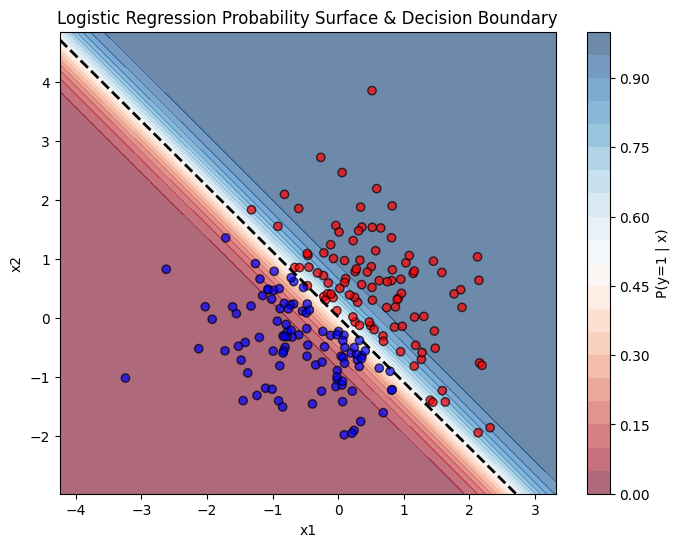

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Generate synthetic 2D data
np.random.seed(42)
N = 200
X = np.random.randn(N, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Fit logistic regression
clf = LogisticRegression()
clf.fit(X, y)

# Grid for probability surface
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot probability surface and decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='P(y=1 | x)')
plt.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', alpha=0.7)
plt.title('Logistic Regression Probability Surface & Decision Boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

For each input, logistic regression models the probability that the output (class label) is 1 (or "success") using the logistic (sigmoid) function. The predicted probability is interpreted as the parameter of a Bernoulli distribution, so the output for each sample is assumed to be drawn from a Bernoulli distribution with probability ( p = \sigma(w^T x + b) ), where ( \sigma ) is the sigmoid function.

Summary:

The underlying distribution for inference in logistic regression is the Bernoulli distribution.
The model estimates the probability of class membership, and each prediction is a Bernoulli trial (success/failure, 1/0).

## Multi-Label-Classification

In [6]:
import pandas as pd
import torch.nn as nn
from sklearn.model_selection import train_test_split

data = pd.read_csv("/media/guru/e3dd0686-a58b-467b-913b-60b095056804/Deep_Gen_AI/poster_images/Multi_Label_dataset/train.csv")
data.head()

,Id,Genre,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,...,N/A,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
0,tt0086425,"['Comedy', 'Drama']",0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,tt0085549,"['Drama', 'Romance', 'Music']",0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,tt0086465,['Comedy'],0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,tt0086567,"['Sci-Fi', 'Thriller']",0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,tt0086034,"['Action', 'Adventure', 'Thriller']",1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [7]:
data.isnull().sum()

Id             0
Genre          0
Action         0
Adventure      0
Animation      0
Biography      0
Comedy         0
Crime          0
Documentary    0
Drama          0
Family         0
Fantasy        0
History        0
Horror         0
Music          0
Musical        0
Mystery        0
N/A            0
News           0
Reality-TV     0
Romance        0
Sci-Fi         0
Short          0
Sport          0
Thriller       0
War            0
Western        0
dtype: int64

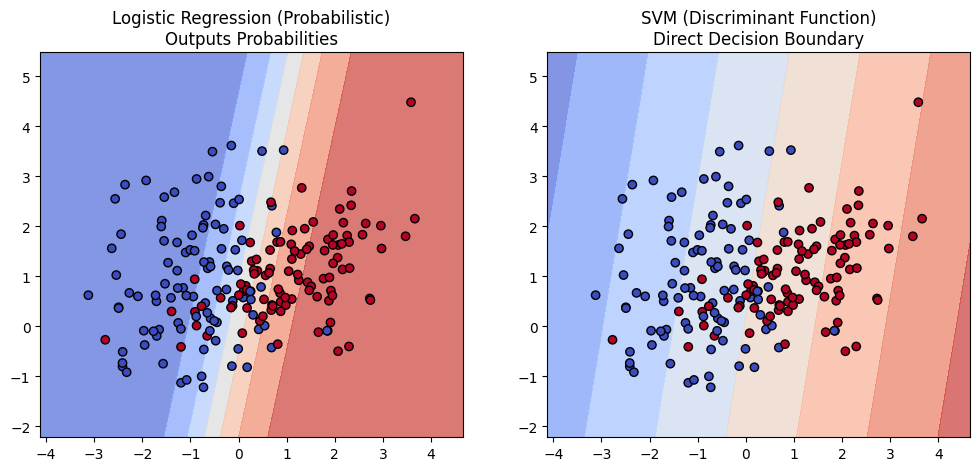

In [8]:
# Re-run after reset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Create a simple dataset
X, y = make_classification(n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_samples=200, random_state=42)

# 2. Train models
log_reg = LogisticRegression()
log_reg.fit(X, y)

svm_clf = SVC(kernel="linear", probability=False)  # SVM without probabilities
svm_clf.fit(X, y)

# 3. Prepare meshgrid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Logistic Regression probabilities
probs = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

# SVM decision function (distance to boundary)
decision = svm_clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression plot
cs = axes[0].contourf(xx, yy, probs, cmap="coolwarm", alpha=0.7)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
axes[0].set_title("Logistic Regression (Probabilistic)\nOutputs Probabilities")

# SVM plot
cs = axes[1].contourf(xx, yy, decision, cmap="coolwarm", alpha=0.7)
axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
axes[1].set_title("SVM (Discriminant Function)\nDirect Decision Boundary")

plt.show()


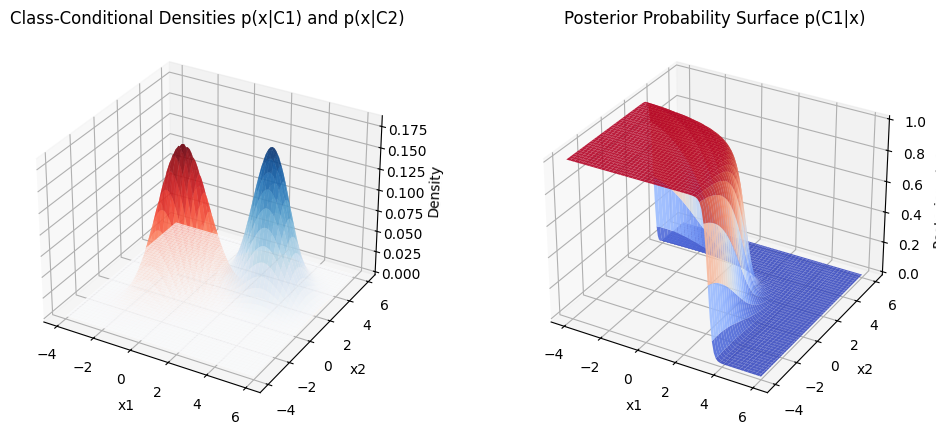

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# ----------------------------
# Parameters of 2 Gaussians
# ----------------------------
mu1 = np.array([0, 0])       # mean of class 1
cov1 = np.array([[1, 0.5],
                 [0.5, 1]])  # covariance of class 1

mu2 = np.array([3, 3])       # mean of class 2
cov2 = np.array([[1, -0.3],
                 [-0.3, 1]]) # covariance of class 2

# Priors
pi1, pi2 = 0.5, 0.5

# ----------------------------
# Grid of points
# ----------------------------
x = np.linspace(-4, 6, 100)
y = np.linspace(-4, 6, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# ----------------------------
# Class-conditional densities
# ----------------------------
p_x_given_c1 = multivariate_normal.pdf(pos, mean=mu1, cov=cov1)
p_x_given_c2 = multivariate_normal.pdf(pos, mean=mu2, cov=cov2)

# ----------------------------
# Posterior using Bayes rule
# ----------------------------
posterior_c1 = (pi1 * p_x_given_c1) / (pi1 * p_x_given_c1 + pi2 * p_x_given_c2)

# ----------------------------
# Plot Class-conditional Densities
# ----------------------------
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection="3d")
ax1.plot_surface(X, Y, p_x_given_c1, cmap="Reds", edgecolor="none", alpha=0.7)
ax1.plot_surface(X, Y, p_x_given_c2, cmap="Blues", edgecolor="none", alpha=0.7)
ax1.set_title("Class-Conditional Densities p(x|C1) and p(x|C2)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("Density")

# ----------------------------
# Plot Posterior Surface
# ----------------------------
ax2 = fig.add_subplot(122, projection="3d")
ax2.plot_surface(X, Y, posterior_c1, cmap="coolwarm", edgecolor="none", alpha=0.9)
ax2.set_title("Posterior Probability Surface p(C1|x)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("Posterior p(C1|x)")

plt.show()
